In [1]:
!pip install statsmodels

In [ ]:
#trimestre 1 de 1989 4to trim de 2019

In [25]:
import pandas as pd
df = pd.read_excel('/content/Primer_Data_ad.xlsx')
df['trimestre'] = pd.PeriodIndex(df['Unnamed: 0'], freq='Q')
df = df.set_index('trimestre')
df = df.drop(columns=['Unnamed: 0'])

from statsmodels.tsa.api import VAR

# Cada columna es una variable endógena
variables = ["Real GDP","1-year T-Bill"]
datos_var = df[variables]
# Crear el modelo
modelo = VAR(datos_var)

resultado = modelo.fit(1, trend="c",)
print(resultado.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 07, Aug, 2026
Time:                     03:56:21
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -3.12494
Nobs:                     122.000    HQIC:                  -3.20683
Log likelihood:          -141.187    FPE:                  0.0382801
AIC:                     -3.26284    Det(Omega_mle):       0.0364647
--------------------------------------------------------------------
Results for equation Real GDP
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.363026         0.090645            4.005           0.000
L1.Real GDP              0.378753         0.085746            4.417           0.000
L1.1-year T-Bill         0.004102         0.0

In [26]:
resultado.sigma_u

,Real GDP,1-year T-Bill
Real GDP,0.289091,0.078151
1-year T-Bill,0.078151,0.147263


In [46]:
import numpy as np

Sigma = resultado.sigma_u

a = np.sqrt(Sigma.iloc[0,0])
print(f"a = {a}")

b = Sigma.iloc[1,0] / a
print(f"b = {b}")

c = np.sqrt(Sigma.iloc[1,1] - b**2)
print(f"c = {c}")

a = 0.537672001782736
b = 0.14535126217852076
c = 0.35515586644397307


In [49]:
A = resultado.coefs[0]
print(A)

[[0.37875261 0.0041021 ]
 [0.26072723 0.95406355]]


In [47]:
P = np.linalg.cholesky(resultado.sigma_u)
print(P)

[[0.537672   0.        ]
 [0.14535126 0.35515587]]


In [53]:
#Impacto contemporaneo
shock = np.array([1,0])
impacto = P @ shock
print(impacto)

[0.537672   0.14535126]


In [56]:
#Horizont 1
u1 = A @ impacto
print(u1)

[0.20424092 0.27886007]


In [58]:
#Horizonte 2
u2 = A @ u1
print(u2)

[0.07850069 0.3193014 ]


 Horizonte      Variable 1      Variable 2
-------------------------------------------
    0         0.000000         0.355156
    1         0.001457         0.338841
    2         0.001942         0.323656
    3         0.002063         0.309295
    4         0.002050         0.295625
    5         0.001989         0.282579
    6         0.001913         0.270117
    7         0.001832         0.258208
    8         0.001753         0.246824
    9         0.001677         0.235943
   10         0.001603         0.225542
   11         0.001532         0.215599
   12         0.001465         0.206095
   13         0.001400         0.197009
   14         0.001338         0.188325
   15         0.001279         0.180023
   16         0.001223         0.172087
   17         0.001169         0.164500
   18         0.001118         0.157249
   19         0.001068         0.150317
   20         0.001021         0.143690
   21         0.000976         0.137356
   22         0.000933         0.

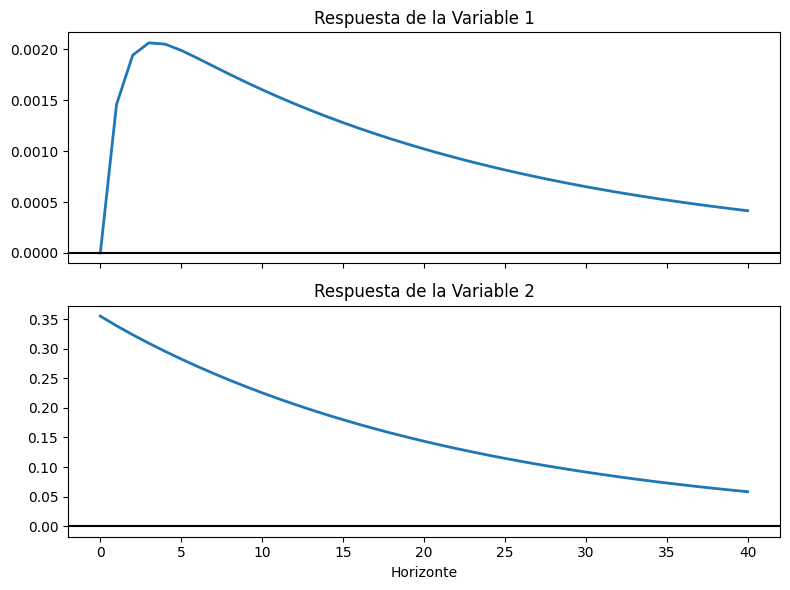

In [61]:
import numpy as np
import matplotlib.pyplot as plt

#==========================
# CHOQUE ESTRUCTURAL
#==========================

# Choque de una desviación estándar sobre la primera variable
shock = np.array([0, 1])

# Horizonte
H = 40

#==========================
# IMPACTO INICIAL
#==========================

impacto = P @ shock

# Matriz donde se guardarán las respuestas
IRF = np.zeros((H + 1, 2))

IRF[0] = impacto

#==========================
# PROPAGACIÓN DEL CHOQUE
#==========================

for h in range(H):

    IRF[h + 1] = A @ IRF[h]

#==========================
# IMPRIMIR RESULTADOS
#==========================

print(" Horizonte      Variable 1      Variable 2")
print("-------------------------------------------")

for h in range(H + 1):

    print(f"{h:>5} {IRF[h,0]:>16.6f} {IRF[h,1]:>16.6f}")

#==========================
# GRAFICAR
#==========================

fig, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True)

ax[0].plot(IRF[:,0], lw=2)
ax[0].axhline(0, color='black')
ax[0].set_title("Respuesta de la Variable 1")

ax[1].plot(IRF[:,1], lw=2)
ax[1].axhline(0, color='black')
ax[1].set_title("Respuesta de la Variable 2")

ax[1].set_xlabel("Horizonte")

plt.tight_layout()
plt.show()